In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [40]:
df = pd.read_csv("Estadistica.csv")

In [41]:
df.columns

Index(['Marca temporal', '¿Qué edad tienes?',
       '¿Qué dispositivos usas principalmente?',
       '¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?',
       '  ¿Cuántas horas diarias pasas, en promedio, específicamente en Redes Sociales? (Instagram, TikTok, Twitter/X, etc.)  ',
       '  ¿Cuál es tu promedio académico actual o estimado en este ciclo lectivo? (Nota del 1 al 10)  ',
       '¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil durante los fines de semana?',
       '¿Cuál es la principal actividad que realiza en su dispositivo móvil?',
       'Indique en qué rango de tiempo usted suele revisar su dispositivo con mayor frecuencia. [Lunes a Viernes]',
       'Indique en qué rango de tiempo usted suele revisar su dispositivo con mayor frecuencia. [Sábados y Domingos]',
       'Evalúe su nivel de dependencia del dispositivo móvil (1 siendo muy baja y 10 siendo muy alta).',
       '¿Considera que su uso de pa

Aqui elegimos las columnas que necesitamos para poder utilizar las siguientes variables que se piden 

In [42]:
columnas_de_interes = ['¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?','¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil durante los fines de semana?','  ¿Cuál es tu promedio académico actual o estimado en este ciclo lectivo? (Nota del 1 al 10)  ','¿Cuál es la principal actividad que realiza en su dispositivo móvil?']

In [43]:
df_reducido = df[columnas_de_interes]
df_reducido

,"¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?","¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil durante los fines de semana?",¿Cuál es tu promedio académico actual o estimado en este ciclo lectivo? (Nota del 1 al 10),¿Cuál es la principal actividad que realiza en su dispositivo móvil?
0,1 a 2 horas,4 a 6 horas,9,"Redes sociales (Instagram, TikTok, Facebook, X..."
1,4 a 6 horas,Más de 6 horas,7,"Consumo de video (YouTube, Netflix), Juegos (M..."
2,4 a 6 horas,Más de 6 horas,8,"Consumo de video (YouTube, Netflix)"
3,1 a 2 horas,Menos de 1 hora,8,"Redes sociales (Instagram, TikTok, Facebook, X..."
4,4 a 6 horas,4 a 6 horas,8,"Redes sociales (Instagram, TikTok, Facebook, X..."
...,...,...,...,...
195,Más de 6 horas,Más de 6 horas,9,"Redes sociales (Instagram, TikTok, Facebook, X..."
196,2 a 4 horas,Más de 6 horas,9,"Redes sociales (Instagram, TikTok, Facebook, X..."
197,Más de 6 horas,2 a 4 horas,7,"Comunicación (WhatsApp, Telegram, llamadas)"
198,Más de 6 horas,1 a 2 horas,9,"Redes sociales (Instagram, TikTok, Facebook, X..."


In [44]:
df_reducido.columns = ['Horas_De_Uso_Entre_Semana', 'Horas_De_Uso_Fin_De_Semana', 'Promedio_Academico', 'Actividad_Principal']

df_reducido = df_reducido[df_reducido['Actividad_Principal'].str.contains("Redes sociales", na=False)]

mapeo_intervalos = {
    "Menos de 1 hora": 0.5,
    "1 a 2 horas": 1.5,
    "2 a 4 horas": 3.0,
    "4 a 6 horas": 5.0,
    "Más de 6 horas": 7.0
}

df_reducido['Horas_De_Uso_Entre_Semana'] = df_reducido['Horas_De_Uso_Entre_Semana'].map(mapeo_intervalos)
df_reducido['Horas_De_Uso_Fin_De_Semana'] = df_reducido['Horas_De_Uso_Fin_De_Semana'].map(mapeo_intervalos)
df_reducido['Promedio_Academico'] = pd.to_numeric(df_reducido['Promedio_Academico'], errors='coerce')

print(df_reducido)

     Horas_De_Uso_Entre_Semana  Horas_De_Uso_Fin_De_Semana  \
0                          1.5                         5.0   
3                          1.5                         0.5   
4                          5.0                         5.0   
6                          7.0                         7.0   
8                          3.0                         5.0   
..                         ...                         ...   
194                        3.0                         5.0   
195                        7.0                         7.0   
196                        3.0                         7.0   
198                        7.0                         1.5   
199                        7.0                         7.0   

     Promedio_Academico                                Actividad_Principal  
0                     9  Redes sociales (Instagram, TikTok, Facebook, X...  
3                     8  Redes sociales (Instagram, TikTok, Facebook, X...  
4                     8 

In [58]:
df_reducido.dtypes

Horas_De_Uso_Entre_Semana     float64
Horas_De_Uso_Fin_De_Semana    float64
Promedio_Academico              int64
Actividad_Principal               str
dtype: object

In [ ]:
# 1. Buscar la columna de horas en redes sociales de forma dinámica
col_redes = [c for c in df.columns if 'redes sociales' in c.lower() and 'horas diarias' in c.lower()][0]

# 2. Extraer solo el número por si quedaron textos
df[col_redes] = df[col_redes].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# 3. Preparar los datos válidos y ordenarlos
datos = df[col_redes].dropna().sort_values()
n = len(datos)

# 4. Generar la Tabla de frecuencias
valores = sorted(datos.unique())
tabla = []

fi_acum = 0
hi_acum = 0

for i, valor in enumerate(valores, start=1):
    fi = (datos == valor).sum()          # Frecuencia absoluta
    hi = fi / n                          # Frecuencia relativa
    pi = hi * 100                        # Porcentaje (Corregido el *)
    fi_acum += fi                        # Frecuencia absoluta acumulada
    hi_acum += hi                        # Frecuencia relativa acumulada
    pi_acum = hi_acum * 100              # Porcentaje acumulado

    tabla.append({
        'i': i,
        'xi (horas)': valor,
        'fi (frec. abs.)': fi,
        'Fi (frec. abs. acum.)': fi_acum,
        'hi (frec. rel.)': round(hi, 4),
        'Hi (frec. rel. acum.)': round(hi_acum, 4),
        'pi (%)': round(pi, 2),
        'Pi (% acum.)': round(pi_acum, 2)
    })

# Convertir la lista de diccionarios en un DataFrame de Pandas
tabla_df = pd.DataFrame(tabla)

# 5. Fila de totales finales
totales = {
    'i': 'Total',
    'xi (horas)': '-',
    'fi (frec. abs.)': n,
    'Fi (frec. abs. acum.)': '-',
    'hi (frec. rel.)': 1.0,
    'Hi (frec. rel. acum.)': '-',
    'pi (%)': 100.0,
    'Pi (% acum.)': '-'
}

# Unir la tabla con la fila de totales
tabla_df = pd.concat([tabla_df, pd.DataFrame([totales])], ignore_index=True)

# 6. Mostrar el resultado final idéntico a tu formato
print(tabla_df.to_string(index=False))

    i xi (horas)  fi (frec. abs.) Fi (frec. abs. acum.)  hi (frec. rel.) Hi (frec. rel. acum.)  pi (%) Pi (% acum.)
    1        1.0               30                    30           0.1829                0.1829   18.29        18.29
    2        2.0               41                    71           0.2500                0.4329   25.00        43.29
    3        2.3                1                    72           0.0061                 0.439    0.61         43.9
    4        3.0               17                    89           0.1037                0.5427   10.37        54.27
    5        4.0               31                   120           0.1890                0.7317   18.90        73.17
    6        5.0                8                   128           0.0488                0.7805    4.88        78.05
    7        6.0               15                   143           0.0915                 0.872    9.15         87.2
    8        7.0                3                   146           0.0183

In [46]:
# --- CÓDIGO PARA GENERAR LAS INTERPRETACIONES AUTOMÁTICAMENTE ---

print("\n=== INTERPRETACIÓN DE RESULTADOS ===")

# Función auxiliar para obtener un valor de la tabla de forma segura
def obtener_dato(fila_i, columna):
    try:
        # Filtramos por el índice 'i' asignado en tu tabla
        return tabla_df[tabla_df['i'] == fila_i][columna].values[0]
    except:
        return "[No aplica / Fila no existente]"

# 1. Frecuencias Absolutas (f)
print(f"● f₂: {obtener_dato(2, 'fi (frec. abs.)')} estudiantes pasan exactamente {obtener_dato(2, 'xi (horas)')} horas diarias en redes sociales.")
print(f"● f₅: {obtener_dato(5, 'fi (frec. abs.)')} estudiantes pasan exactamente {obtener_dato(5, 'xi (horas)')} horas diarias en redes sociales.")
print(f"● f₈: {obtener_dato(8, 'fi (frec. abs.)')} estudiantes pasan exactamente {obtener_dato(8, 'xi (horas)')} horas diarias en redes sociales.")

# 2. Frecuencias Acumuladas (F)
print(f"● F₄: Un total de {obtener_dato(4, 'Fi (frec. abs. acum.)')} estudiantes pasan {obtener_dato(4, 'xi (horas)')} horas o menos al día en redes sociales.")
print(f"● F₇: Un total de {obtener_dato(7, 'Fi (frec. abs. acum.)')} estudiantes pasan {obtener_dato(7, 'xi (horas)')} horas o menos al día en redes sociales.")
print(f"● F₁₀: Un total de {obtener_dato(10, 'Fi (frec. abs. acum.)')} estudiantes pasan {obtener_dato(10, 'xi (horas)')} horas o menos al día en redes sociales.")

# 3. Porcentajes Simples (p)
print(f"● p₃: El {obtener_dato(3, 'pi (%)')}% del total de estudiantes utiliza las redes sociales exactamente {obtener_dato(3, 'xi (horas)')} horas diarias.")
print(f"● p₆: El {obtener_dato(6, 'pi (%)')}% del total de estudiantes utiliza las redes sociales exactamente {obtener_dato(6, 'xi (horas)')} horas diarias.")
print(f"● p₉: El {obtener_dato(9, 'pi (%)')}% del total de estudiantes utiliza las redes sociales exactamente {obtener_dato(9, 'xi (horas)')} horas diarias.")

# 4. Porcentajes Acumulados (P)
print(f"● P₈: El {obtener_dato(8, 'Pi (% acum.)')}% de los estudiantes analizados pasa {obtener_dato(8, 'xi (horas)')} horas o menos al día en redes sociales.")
print(f"● P₁₂: El {obtener_dato(12, 'Pi (% acum.)')}% de los estudiantes analizados pasa {obtener_dato(12, 'xi (horas)')} horas o menos al día en redes sociales.")


=== INTERPRETACIÓN DE RESULTADOS ===
● f₂: 41 estudiantes pasan exactamente 2.0 horas diarias en redes sociales.
● f₅: 31 estudiantes pasan exactamente 4.0 horas diarias en redes sociales.
● f₈: 3 estudiantes pasan exactamente 7.0 horas diarias en redes sociales.
● F₄: Un total de 89 estudiantes pasan 3.0 horas o menos al día en redes sociales.
● F₇: Un total de 143 estudiantes pasan 6.0 horas o menos al día en redes sociales.
● F₁₀: Un total de 156 estudiantes pasan 10.0 horas o menos al día en redes sociales.
● p₃: El 0.61% del total de estudiantes utiliza las redes sociales exactamente 2.3 horas diarias.
● p₆: El 4.88% del total de estudiantes utiliza las redes sociales exactamente 5.0 horas diarias.
● p₉: El 4.27% del total de estudiantes utiliza las redes sociales exactamente 8.0 horas diarias.
● P₈: El 89.02% de los estudiantes analizados pasa 7.0 horas o menos al día en redes sociales.
● P₁₂: El 99.39% de los estudiantes analizados pasa 20.0 horas o menos al día en redes social

In [47]:
# --- CÓDIGO PARA RESOLVER EL PUNTO E ---

print("\n=== RESULTADOS DEL PUNTO E ===")

# Aseguramos que trabajamos con las filas que tienen datos numéricos reales (excluyendo la fila de 'Total')
df_valores = tabla_df[tabla_df['i'] != 'Total'].copy()

# 1. Cantidad entre 3 y 8 horas
cant_3_8 = df_valores[df_valores['xi (horas)'].between(3, 8)]['fi (frec. abs.)'].sum()
print(f"● Cantidad de estudiantes que utilizan entre 3 y 8 horas diarias las redes sociales: {int(cant_3_8)}")

# 2. Porcentaje de más de 6 horas
pct_mas_6 = df_valores[df_valores['xi (horas)'] > 6]['pi (%)'].sum()
print(f"● Porcentaje de estudiantes que utilizan más de 6 horas diarias las redes sociales: {round(pct_mas_6, 2)}%")

# 3. Cantidad de menos de 2 horas
cant_menos_2 = df_valores[df_valores['xi (horas)'] < 2]['fi (frec. abs.)'].sum()
print(f"● Cantidad de estudiantes que utilizan menos de 2 horas diarias las redes sociales: {int(cant_menos_2)}")

# 4. Porcentaje entre 5 y 10 horas
pct_5_10 = df_valores[df_valores['xi (horas)'].between(5, 10)]['pi (%)'].sum()
print(f"● Porcentaje de estudiantes que utilizan entre 5 y 10 horas diarias las redes sociales: {round(pct_5_10, 2)}%")

# 5. Cantidad de más de 8 horas
cant_mas_8 = df_valores[df_valores['xi (horas)'] > 8]['fi (frec. abs.)'].sum()
print(f"● Cantidad de estudiantes que utilizan más de 8 horas diarias las redes sociales: {int(cant_mas_8)}")

# 6. Porcentaje de menos de 4 horas
pct_menos_4 = df_valores[df_valores['xi (horas)'] < 4]['pi (%)'].sum()
print(f"● Porcentaje de estudiantes que utilizan menos de 4 horas diarias las redes sociales: {round(pct_menos_4, 2)}%")

# 7. Cantidad entre 1 y 6 horas
cant_1_6 = df_valores[df_valores['xi (horas)'].between(1, 6)]['fi (frec. abs.)'].sum()
print(f"● Cantidad de estudiantes que utilizan entre 1 y 6 horas diarias las redes sociales: {int(cant_1_6)}")

# 8. Porcentaje de más de 9 horas
pct_mas_9 = df_valores[df_valores['xi (horas)'] > 9]['pi (%)'].sum()
print(f"● Porcentaje de estudiantes que utilizan más de 9 horas diarias las redes sociales: {round(pct_mas_9, 2)}%")


=== RESULTADOS DEL PUNTO E ===
● Cantidad de estudiantes que utilizan entre 3 y 8 horas diarias las redes sociales: 81
● Porcentaje de estudiantes que utilizan más de 6 horas diarias las redes sociales: 12.81%
● Cantidad de estudiantes que utilizan menos de 2 horas diarias las redes sociales: 30
● Porcentaje de estudiantes que utilizan entre 5 y 10 horas diarias las redes sociales: 21.96%
● Cantidad de estudiantes que utilizan más de 8 horas diarias las redes sociales: 11
● Porcentaje de estudiantes que utilizan menos de 4 horas diarias las redes sociales: 54.27%
● Cantidad de estudiantes que utilizan entre 1 y 6 horas diarias las redes sociales: 143
● Porcentaje de estudiantes que utilizan más de 9 horas diarias las redes sociales: 6.71%


$$\sum f_i = n$$

$$X_i = \frac{L_i + L_s}{2}$$

In [ ]:
df_calc = tabla_df[tabla_df['i'] != 'Total'].copy()

df_calc['xi (horas)'] = df_calc['xi (horas)'].astype(float)
df_calc['fi (frec. abs.)'] = df_calc['fi (frec. abs.)'].astype(float)
df_calc['Fi (frec. abs. acum.)'] = df_calc['Fi (frec. abs. acum.)'].astype(float)

n = df_calc['fi (frec. abs.)'].sum()

media = (df_calc['xi (horas)'] * df_calc['fi (frec. abs.)']).sum() / n

posicion_mediana = n / 2
# CORREGIDO: Removidas las comillas alrededor de posicion_mediana
fila_mediana = df_calc[df_calc['Fi (frec. abs. acum.)'] >= posicion_mediana].iloc[0]
mediana = fila_mediana['xi (horas)']

fila_moda = df_calc[df_calc['fi (frec. abs.)'] == df_calc['fi (frec. abs.)'].max()].iloc[0]
moda = fila_moda['xi (horas)']

desviacion_std = np.sqrt(((df_calc['xi (horas)'] - media)**2 * df_calc['fi (frec. abs.)']).sum() / n)

asimetria = (((df_calc['xi (horas)'] - media)**3 * df_calc['fi (frec. abs.)']).sum() / n) / (desviacion_std**3)

curtosis = ((((df_calc['xi (horas)'] - media)**4 * df_calc['fi (frec. abs.)']).sum() / n) / (desviacion_std**4)) - 3

print("=== MEDIDAS ESTADÍSTICAS ===")
print(f"● Media aritmética: {round(media, 2)} horas")
print(f"● Mediana: {round(mediana, 2)} horas")
print(f"● Moda: {round(moda, 2)} horas")
print(f"● Coeficiente de asimetría: {round(asimetria, 4)}")
print(f"● Curtosis: {round(curtosis, 4)}")

=== MEDIDAS ESTADÍSTICAS ===
● Media aritmética: 4.04 horas
● Mediana: 3.0 horas
● Moda: 2.0 horas
● Coeficiente de asimetría: 2.857
● Curtosis: 10.0068


In [49]:
df_disp = tabla_df[tabla_df['i'] != 'Total'].copy()

df_disp['xi (horas)'] = df_disp['xi (horas)'].astype(float)
df_disp['fi (frec. abs.)'] = df_disp['fi (frec. abs.)'].astype(float)

n = df_disp['fi (frec. abs.)'].sum()

media = (df_disp['xi (horas)'] * df_disp['fi (frec. abs.)']).sum() / n

varianza = ((df_disp['xi (horas)'] - media)**2 * df_disp['fi (frec. abs.)']).sum() / n

desvio_std = np.sqrt(varianza)

coef_variacion = (desvio_std / media) * 100

print("=== MEDIDAS DE DISPERSIÓN ===")
print(f"● Varianza: {round(varianza, 4)}")
print(f"● Desvío estándar: {round(desvio_std, 2)} horas")
print(f"● Coeficiente de variación: {round(coef_variacion, 2)}%")

=== MEDIDAS DE DISPERSIÓN ===
● Varianza: 14.2656
● Desvío estándar: 3.78 horas
● Coeficiente de variación: 93.39%


In [50]:


df_pos = tabla_df[tabla_df['i'] != 'Total'].copy()

df_pos['xi (horas)'] = df_pos['xi (horas)'].astype(float)
df_pos['Fi (frec. abs. acum.)'] = df_pos['Fi (frec. abs. acum.)'].astype(float)

n = df_pos['fi (frec. abs.)'].astype(float).sum()

def calcular_percentil_agrupado(k):
    posicion = (k * n) / 100
    fila = df_pos[df_pos['Fi (frec. abs. acum.)'] >= posicion].iloc[0]
    return fila['xi (horas)']

q1 = calcular_percentil_agrupado(25)
q3 = calcular_percentil_agrupado(75)

d3 = calcular_percentil_agrupado(30)
d4 = calcular_percentil_agrupado(40)
d9 = calcular_percentil_agrupado(90)

p23 = calcular_percentil_agrupado(23)
p75 = calcular_percentil_agrupado(75)
p97 = calcular_percentil_agrupado(97)

print("=== CUANTILES (MEDIDAS DE POSICIÓN) ===")
print(f"● Cuartiles: Q1 = {round(q1, 2)} horas | Q3 = {round(q3, 2)} horas")
print(f"● Deciles: D3 = {round(d3, 2)} horas | D4 = {round(d4, 2)} horas | D9 = {round(d9, 2)} horas")
print(f"● Percentiles: P23 = {round(p23, 2)} horas | P75 = {round(p75, 2)} horas | P97 = {round(p97, 2)} horas")

=== CUANTILES (MEDIDAS DE POSICIÓN) ===
● Cuartiles: Q1 = 2.0 horas | Q3 = 5.0 horas
● Deciles: D3 = 2.0 horas | D4 = 2.0 horas | D9 = 8.0 horas
● Percentiles: P23 = 2.0 horas | P75 = 5.0 horas | P97 = 20.0 horas


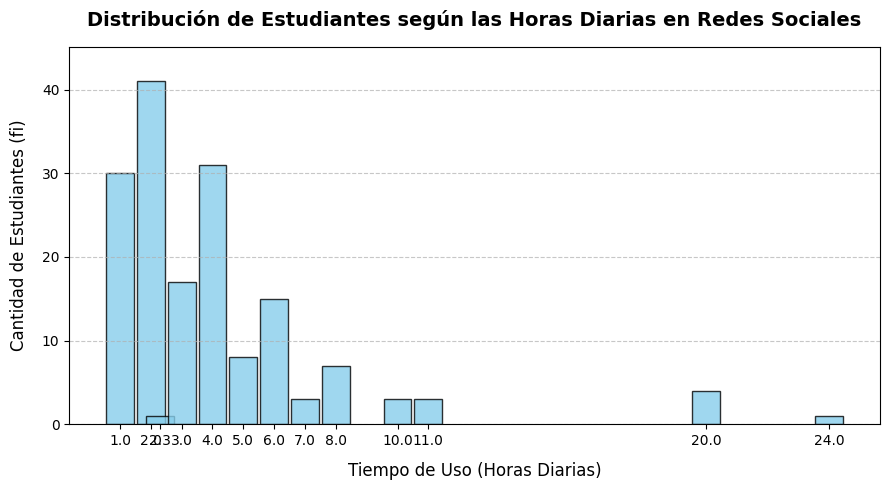

In [51]:
df_graf = tabla_df[tabla_df['i'] != 'Total'].copy()

df_graf['xi (horas)'] = df_graf['xi (horas)'].astype(float)
df_graf['fi (frec. abs.)'] = df_graf['fi (frec. abs.)'].astype(float)

plt.figure(figsize=(9, 5))

plt.bar(
    df_graf['xi (horas)'], 
    df_graf['fi (frec. abs.)'], 
    width=0.9, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.8
)

plt.title('Distribución de Estudiantes según las Horas Diarias en Redes Sociales', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Tiempo de Uso (Horas Diarias)', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Estudiantes (fi)', fontsize=12, labelpad=10)

plt.xticks(df_graf['xi (horas)'])
plt.ylim(0, df_graf['fi (frec. abs.)'].max() + (df_graf['fi (frec. abs.)'].max() * 0.1))

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

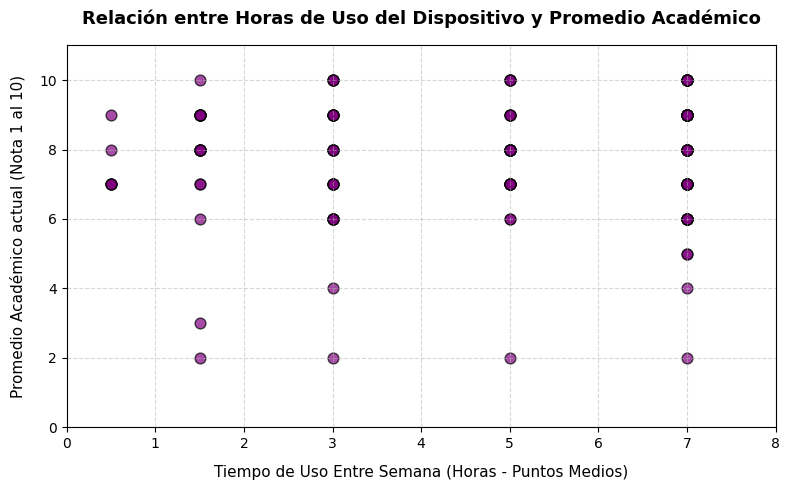

In [52]:
# 1. Leer el archivo directamente de cero
df_nuevo = pd.read_csv("Estadistica.csv")

# 2. Buscar las columnas por coincidencia de texto exacta para no cruzarlas
col_actividad = [c for c in df_nuevo.columns if 'actividad' in c.lower()][0]
col_horas = [c for c in df_nuevo.columns if 'horas al día' in c.lower() and 'laborables' in c.lower()][0]
col_promedio = [c for c in df_nuevo.columns if 'promedio académico' in c.lower() or 'nota del 1 al 10' in c.lower()][0]

# 3. Filtrar los usuarios de Redes Sociales
df_filtrado = df_nuevo[df_nuevo[col_actividad].str.contains("Redes sociales", na=False)].copy()

# 4. Mapear ÚNICAMENTE las horas (eje X)
mapeo_intervalos = {
    "Menos de 1 hora": 0.5,
    "1 a 2 horas": 1.5,
    "2 a 4 horas": 3.0,
    "4 a 6 horas": 5.0,
    "Más de 6 horas": 7.0
}
x_datos = df_filtrado[col_horas].map(mapeo_intervalos)

# 5. Convertir las notas a números SIN aplicar el mapa de horas (eje Y)
y_datos = pd.to_numeric(df_filtrado[col_promedio], errors='coerce')

# 6. Unir y limpiar vacíos
df_grafico = pd.DataFrame({'Horas': x_datos, 'Notas': y_datos}).dropna()

# 7. Dibujar el diagrama de dispersión real
plt.figure(figsize=(8, 5))
plt.scatter(df_grafico['Horas'], df_grafico['Notas'], color='purple', alpha=0.7, edgecolors='black', s=60)

plt.title('Relación entre Horas de Uso del Dispositivo y Promedio Académico', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Tiempo de Uso Entre Semana (Horas - Puntos Medios)', fontsize=11, labelpad=10)
plt.ylabel('Promedio Académico actual (Nota 1 al 10)', fontsize=11, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 8)
plt.ylim(0, 11)

plt.tight_layout()
plt.show()

b) Análisis de la correlación observada:
A partir del diagrama de dispersión construido, se observa una correlación lineal prácticamente nula (o extremadamente débil). Los puntos se distribuyen de forma dispersa en columnas verticales sin mostrar una tendencia o inclinación visualmente definida (sea ascendente o descendente). Esto sugiere de forma preliminar que, en la muestra analizada, las variaciones en las horas de uso del dispositivo móvil no dictan de manera directa o predecible el promedio académico de los estudiantes, existiendo un alto grado de dispersión en las notas para cualquier nivel de uso horario.

$$m = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sum (X_i - \bar{X})^2} = \frac{S_{XY}}{S_X^2}$$



$$Y = mX + b$$

In [53]:
df_regresion = df_reducido[['Horas_De_Uso_Entre_Semana', 'Promedio_Academico']].dropna()

# 2. Calcular la pendiente (m) y la ordenada al origen (b)
m, b = np.polyfit(df_regresion['Horas_De_Uso_Entre_Semana'], df_regresion['Promedio_Academico'], 1)

print("=== RECTA DE REGRESIÓN ===")
print(f"Pendiente (m): {round(m, 4)}")
print(f"Ordenada al origen (b): {round(b, 4)}")
print(f"Ecuación de la recta: Y = {round(m, 4)}*X + {round(b, 4)}")

=== RECTA DE REGRESIÓN ===
Pendiente (m): 0.0317
Ordenada al origen (b): 7.5542
Ecuación de la recta: Y = 0.0317*X + 7.5542


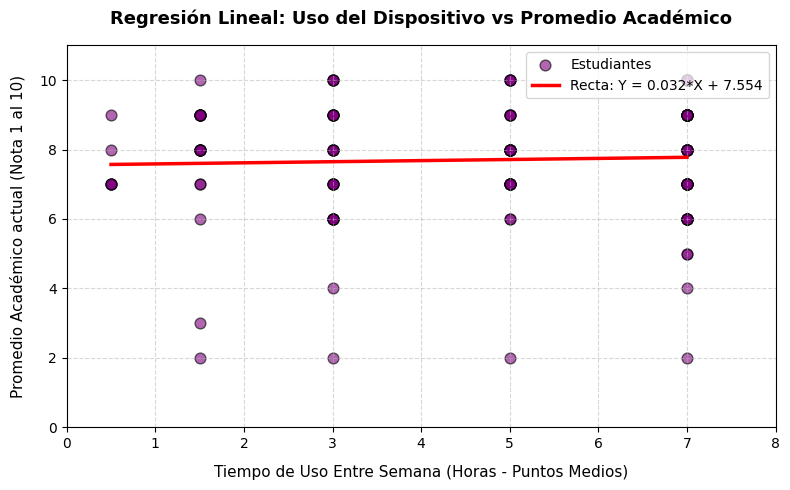

In [54]:
df_regresion = df_reducido[['Horas_De_Uso_Entre_Semana', 'Promedio_Academico']].dropna()
x = df_regresion['Horas_De_Uso_Entre_Semana']
y = df_regresion['Promedio_Academico']

# 2. Calcular los coeficientes de la recta (m = pendiente, b = ordenada)
m, b = np.polyfit(x, y, 1)

# 3. Crear el lienzo del gráfico
plt.figure(figsize=(8, 5))

# 4. Dibujar la nube de puntos original
plt.scatter(x, y, color='purple', alpha=0.6, edgecolors='black', s=60, label='Estudiantes')

# 5. Dibujar la recta de regresión ajustada
# Generamos puntos en el eje X desde el mínimo al máximo para trazar la línea
x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = m * x_linea + b
plt.plot(x_linea, y_linea, color='red', linestyle='-', linewidth=2.5, label=f'Recta: Y = {round(m,3)}*X + {round(b,3)}')

# 6. Personalización de etiquetas, escalas y leyendas
plt.title('Regresión Lineal: Uso del Dispositivo vs Promedio Académico', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Tiempo de Uso Entre Semana (Horas - Puntos Medios)', fontsize=11, labelpad=10)
plt.ylabel('Promedio Académico actual (Nota 1 al 10)', fontsize=11, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 8)
plt.ylim(0, 11)
plt.legend(loc='upper right', fontsize=10) # Muestra el cuadro explicativo de qué es cada color

plt.tight_layout()
plt.show()

$$b = \bar{Y} - m\bar{X}$$

Si tu pendiente ($m$) dio un número NEGATIVO (por ejemplo, $-0.08$):
d) Interpretación de la pendiente:El valor de la pendiente es $m$. Esto significa que por cada hora adicional diaria que un estudiante utiliza su dispositivo móvil entre semana, su promedio académico estimado disminuye en promedio [el valor de m sin el menos] puntos. Esto confirma una tendencia decreciente, aunque muy leve.
Si tu pendiente ($m$) dio un número POSITIVO o casi CERO (por ejemplo, $0.01$ o $0.00$):
 Interpretación de la pendiente:El valor de la pendiente es $m$. Al ser un valor prácticamente cercano a cero, significa que el aumento en las horas diarias de uso del dispositivo móvil no genera un impacto o cambio significativo apreciable sobre el promedio académico estimado de los estudiantes.

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \cdot \sum (Y_i - \bar{Y})^2}} = \frac{S_{XY}}{S_X \cdot S_Y}$$

In [55]:
matriz_correlacion = df_regresion.corr(method='pearson')
r = matriz_correlacion.iloc[0, 1]

print("=== COEFICIENTE DE CORRELACIÓN ===")
print(f"Coeficiente de correlación (r): {round(r, 4)}")

=== COEFICIENTE DE CORRELACIÓN ===
Coeficiente de correlación (r): 0.041


$$R^2 = r^2$$

In [56]:
r_cuadrado = r ** 2
porcentaje_explicado = r_cuadrado * 100

print("=== COEFICIENTE DE DETERMINACIÓN ===")
print(f"Coeficiente de determinación (R²): {round(r_cuadrado, 6)}")
print(f"Porcentaje de variabilidad explicado: {round(porcentaje_explicado, 2)}%")

=== COEFICIENTE DE DETERMINACIÓN ===
Coeficiente de determinación (R²): 0.001685
Porcentaje de variabilidad explicado: 0.17%


In [57]:
df_reducido.to_csv(r"C:\Users\IPF-2026\Desktop\dataset_estudiantes_reducido.csv", index=False, encoding='utf-8-sig')
print("¡Guardado con éxito en el Escritorio!")

¡Guardado con éxito en el Escritorio!
